In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Loading cleaned 2025 BIXI dataset...")
df = pd.read_csv('../data/processed/bixi_2025_cleaned.csv')

print(f"Successfully loaded {len(df):,} cleaned trip records.")
df.head()

Loading cleaned 2025 BIXI dataset...
Successfully loaded 13,990,411 cleaned trip records.


,STARTSTATIONNAME,STARTSTATIONARRONDISSEMENT,STARTSTATIONLATITUDE,STARTSTATIONLONGITUDE,ENDSTATIONNAME,ENDSTATIONARRONDISSEMENT,ENDSTATIONLATITUDE,ENDSTATIONLONGITUDE,STARTTIMEMS,ENDTIMEMS,duration_sec,start_date,end_date,start_hour,day_of_week,month,is_round_trip
0,St-Viateur / Casgrain,Le Plateau-Mont-Royal,45.53,-73.60,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.55,-73.59,1767118845159,1767119927367.00,1082.21,2025-12-30 18:20:45.159,2025-12-30 18:38:47.367,18,Tuesday,12,False
1,9e avenue / Masson,Rosemont - La Petite-Patrie,45.55,-73.57,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.55,-73.59,1767146967447,1767148054129.00,1086.68,2025-12-31 02:09:27.447,2025-12-31 02:27:34.129,2,Wednesday,12,False
2,St-Urbain / Laurier,Le Plateau-Mont-Royal,45.52,-73.59,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.55,-73.59,1766867149246,1766868275435.00,1126.19,2025-12-27 20:25:49.246,2025-12-27 20:44:35.435,20,Saturday,12,False
3,Parc de Turin (de Lanaudière / Jean-Talon),Villeray—Saint-Michel—Parc-Extension,45.55,-73.61,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.55,-73.59,1767227508567,1767228209866.00,701.30,2026-01-01 00:31:48.567,2026-01-01 00:43:29.866,0,Thursday,1,False
4,Parthenais / du Mont-Royal,Le Plateau-Mont-Royal,45.54,-73.57,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.55,-73.59,1766953764324,1766954798356.00,1034.03,2025-12-28 20:29:24.324,2025-12-28 20:46:38.356,20,Sunday,12,False


In [2]:
hourly_trips = df['start_hour'].value_counts().sort_index().reset_index()
hourly_trips.columns = ['hour', 'trip_count']

hourly_trips['pct_total'] = (hourly_trips['trip_count'] / len(df)) * 100

print("Trip Distribution by Hour of Day:")
display(hourly_trips)

Trip Distribution by Hour of Day:


,hour,trip_count,pct_total
0,0,772540,5.52
1,1,646704,4.62
2,2,527416,3.77
3,3,404285,2.89
4,4,265070,1.89
5,5,169443,1.21
6,6,108320,0.77
7,7,84657,0.61
8,8,46418,0.33
9,9,68053,0.49


In [3]:
top_start = df['STARTSTATIONNAME'].value_counts().head(10).reset_index()
top_start.columns = ['station_name', 'start_trip_count']
top_start['pct_total_starts'] = (top_start['start_trip_count'] / len(df)) * 100

top_end = df['ENDSTATIONNAME'].value_counts().head(10).reset_index()
top_end.columns = ['station_name', 'end_trip_count']
top_end['pct_total_ends'] = (top_end['end_trip_count'] / len(df)) * 100

print("Top 10 BIXI Starting Stations:")
display(top_start)

print("\nTop 10 BIXI Ending Stations:")
display(top_end)

Top 10 BIXI Starting Stations:


,station_name,start_trip_count,pct_total_starts
0,Métro Mont-Royal (Utilités publiques / Rivard),130078,0.93
1,du Mont-Royal / Clark,119906,0.86
2,Laurier / St-Denis,94727,0.68
3,Laurier / de Brébeuf,73976,0.53
4,des Pins / St-Laurent,72347,0.52
5,Prince-Arthur / du Parc,61968,0.44
6,Métro Peel (de Maisonneuve / Stanley),61487,0.44
7,McTavish / Sherbrooke,58072,0.42
8,Émile-Duployé / Sherbrooke,57404,0.41
9,Berri / Rachel,55674,0.40



Top 10 BIXI Ending Stations:


,station_name,end_trip_count,pct_total_ends
0,Métro Mont-Royal (Utilités publiques / Rivard),112228,0.80
1,du Mont-Royal / Clark,105290,0.75
2,de la Commune / Place Jacques-Cartier,77312,0.55
3,Laurier / St-Denis,73817,0.53
4,Laurier / de Brébeuf,73802,0.53
5,Métro St-Laurent (de Maisonneuve / St-Laurent),73016,0.52
6,Métro Peel (de Maisonneuve / Stanley),68003,0.49
7,des Pins / St-Laurent,67489,0.48
8,Ottawa / Young,62716,0.45
9,Métro Papineau (Dorion / De Maisonneuve),61466,0.44


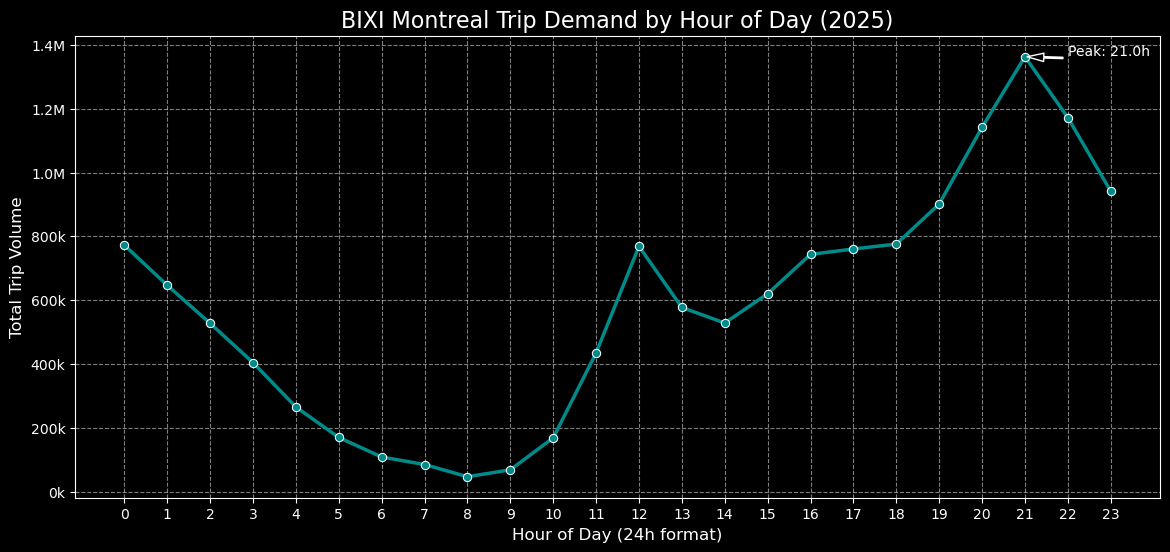

In [9]:
import matplotlib.ticker as ticker
plt.style.use('dark_background')
plt.figure(figsize=(14, 6))

sns.lineplot(data=hourly_trips, x='hour', y='trip_count', marker='o', color='darkcyan', linewidth=2.5)

plt.title('BIXI Montreal Trip Demand by Hour of Day (2025)', fontsize=16)
plt.xlabel('Hour of Day (24h format)', fontsize=12)
plt.ylabel('Total Trip Volume', fontsize=12)
plt.xticks(range(24))
plt.grid(visible=True, linestyle='--', alpha=0.5)

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x*1e-3:,.0f}k' if x < 1e6 else f'{x*1e-6:,.1f}M'))

peak_hour = hourly_trips.loc[hourly_trips['trip_count'].idxmax()]
plt.annotate(f"Peak: {peak_hour.hour}h", xy=(peak_hour.hour, peak_hour.trip_count), xytext=(peak_hour.hour+1, peak_hour.trip_count+5000), arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.show()